### 4.7 Credit Stress & Illustrative ECL

$$PD_{stressed} = \operatorname{clip}\!\big(PD_{base} + s\cdot\Delta u_{cum}/100,\ PD_{base},\ 1.0\big)$$

$$ECL = \dfrac{PD_{stressed}\times LGD\times EAD}{(1+r)^{0.5}}$$

$$ECL_{weighted} = \sum_{scenario} w_{scenario}\,ECL_{scenario}$$

NAB's own disclosed FY2025 Pillar 3 PD/LGD/EAD {cite}`nab2025pillar3`, stressed with
unemployment-sensitivity coefficients from a published RBA research paper
{cite}`garvin2022macrofinancial` (0.4pp personal loans / 0.6pp mortgages per point of
cumulative unemployment change), mid-year discounted at RBA's published lending rates,
and combined with NAB's own 55/42.5/2.5 base/downside/upside scenario weights
{cite}`nab2025annualreport`. **This is 12-month, Stage-1-only and is not a lower bound on
NAB's real provision.** No Stage 2/3 staging logic exists.

:::{dropdown} Show where each input comes from
{glue:}`/00_results_at_a_glance.ipynb::input_sources_fig`

The same diagram is on the [Key Findings](../00_results_at_a_glance) page.
:::

*Source: `src/models/credit_stress.py`, served at `GET /credit-risk/stress-test`*

In [1]:
import sys, warnings
from pathlib import Path

PROJECT_ROOT = Path.cwd()
for _ in range(4):
    if (PROJECT_ROOT / "reports").is_dir() and (PROJECT_ROOT / "data").is_dir():
        break
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.insert(0, str(PROJECT_ROOT))
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

INK, PAPER, ACCENT, ACCENT_SOFT, HIGHLIGHT, GRID = (
    "#16211c", "#f7f8f5", "#1f6f66", "#bfe3dd", "#a8691f", "#d9ddd6",
)
BLUE, PLUM, MUTED, ALERT = "#5b6f8f", "#8a4f8a", "#9aa79f", "#c0392b"
plt.rcParams.update({
    "figure.facecolor": PAPER, "axes.facecolor": PAPER, "axes.edgecolor": GRID,
    "axes.labelcolor": INK, "text.color": INK, "xtick.color": INK, "ytick.color": INK,
    "font.size": 11, "axes.grid": True, "grid.color": GRID, "grid.linewidth": 0.6,
    "axes.spines.top": False, "axes.spines.right": False,
})

import matplotlib.dates as mdates

def year_axis(ax, step=5):
    ax.xaxis.set_major_locator(mdates.YearLocator(step))
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

CURATED = PROJECT_ROOT / "data" / "curated" / "quarterly_macro_features.csv"
TABLEAU = PROJECT_ROOT / "reports" / "tableau"

#### Explained, step by step

- **Stressing the default probability.** Start from NAB's own disclosed baseline probability of default, $PD_{base}$. $\Delta u_{cum}$ is the cumulative *change* in the unemployment rate under a given macro scenario (e.g. +1.5 percentage points cumulative under "downside"), divided by 100 to convert percentage points into a plain fraction. $s$ is a sensitivity coefficient (how much default risk moves per unit of extra unemployment) taken from generic RBA guidance rather than fitted from NAB's own book. $\operatorname{clip}(x, PD_{base}, 1.0)$ enforces two sanity limits: the stressed PD can never fall *below* the baseline (a stress scenario shouldn't look safer than baseline) and can never exceed 100% (a probability can't exceed 1).
- **Expected Credit Loss (ECL).** The standard actuarial formula: probability something defaults ($PD_{stressed}$), times how much would actually be lost if it did ($LGD$, loss given default, as a fraction of exposure), times how much exposure is outstanding ($EAD$, exposure at default), which gives the expected dollar loss. Dividing by $(1+r)^{0.5}$ discounts that loss back to present value assuming it lands, on average, half a year into a 12-month window (the "mid-year" convention), using the RBA's own published lending rate $r$.
- **Blending scenarios.** Rather than reporting one scenario's ECL alone, $ECL_{weighted}$ is a probability-weighted average across upside, base, and downside scenarios, using NAB's own disclosed likelihood weights for each (55% base / 42.5% downside / 2.5% upside), turning three separate what-if numbers into a single expected-value estimate reflecting how likely each scenario is actually thought to be. Carried over from the app verbatim: this is 12-month, Stage-1-only, and explicitly **not** a lower bound on NAB's real provisioning.

#### Where the scenario deltas come from

Before the ECL outcomes below, here's what actually generates the three $\Delta u_{cum}$
values in the formula above: [§4.4](44_svar)'s System B, forecasting its own
`unemployment_rate` variable forward from the 2025Q4 origin, block-bootstrap simulated
(the same `simulate_paths_from_fit` machinery used throughout this section) and read off at each horizon. System A models the same unemployment series, so using System B here is a design choice in the code, not something the data forced.

The stress test below uses horizon 4 (2026Q4, one year ahead) for its downside/base/upside
`p90`/`p50`/`p10` scenario deltas, the three values labelled on the chart.

*Source: `src/models/svar.py::forecast_cumulative_unemployment_change_quantiles`, called
once per horizon 1-8 for this chart; only horizon 4 feeds the live
`GET /credit-risk/stress-test` endpoint and the chart below.*

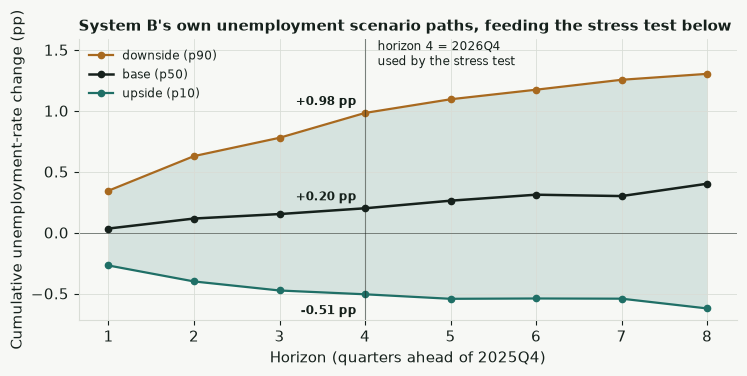

In [2]:
from src.models import svar

STRESS_TEST_HORIZON = 4

records = []
for h in range(1, 9):
    deltas, origin = svar.forecast_cumulative_unemployment_change_quantiles(
        horizon=h, quantiles=(0.9, 0.5, 0.1)
    )
    records.append({"horizon": h, "downside": deltas[0], "base": deltas[1], "upside": deltas[2]})
path = pd.DataFrame(records).set_index("horizon")

fig, ax = plt.subplots(figsize=(7.6, 3.8))
ax.axhline(0, color=INK, linewidth=0.7, alpha=0.5)
ax.fill_between(path.index, path["upside"], path["downside"], color=ACCENT, alpha=0.15, linewidth=0)
ax.plot(path.index, path["downside"], color=HIGHLIGHT, linewidth=1.6, marker="o", markersize=4.5,
        label="downside (p90)")
ax.plot(path.index, path["base"], color=INK, linewidth=1.8, marker="o", markersize=4.5, label="base (p50)")
ax.plot(path.index, path["upside"], color=ACCENT, linewidth=1.6, marker="o", markersize=4.5, label="upside (p10)")
ax.axvline(STRESS_TEST_HORIZON, color=INK, linewidth=0.8, alpha=0.5)
for scenario_name in ("downside", "base", "upside"):
    v = path.loc[STRESS_TEST_HORIZON, scenario_name]
    below = scenario_name == "upside"
    ax.annotate(f"{v:+.2f} pp", (STRESS_TEST_HORIZON, v), xytext=(-6, -12 if below else 8),
                textcoords="offset points", ha="right", va="center", fontsize=8.8, fontweight="bold")
ax.set_ylim(top=path["downside"].max() * 1.22)
ax.text(STRESS_TEST_HORIZON + 0.1, ax.get_ylim()[1], " horizon 4 = 2026Q4\n used by the stress test",
        fontsize=8.3, va="top", ha="left")
ax.set_xlabel("Horizon (quarters ahead of 2025Q4)")
ax.set_ylabel("Cumulative unemployment-rate change (pp)")
ax.set_title("System B's own unemployment scenario paths, feeding the stress test below",
             loc="left", fontsize=11, fontweight="bold")
ax.legend(frameon=False, fontsize=8.5, ncol=1, loc="upper left")
fig.tight_layout()
plt.show()

Those three cumulative unemployment changes are the $\Delta u_{cum}$ in the formulas above. Each one raises the segment's default probability, and the three resulting losses are blended at NAB's own scenario weights:

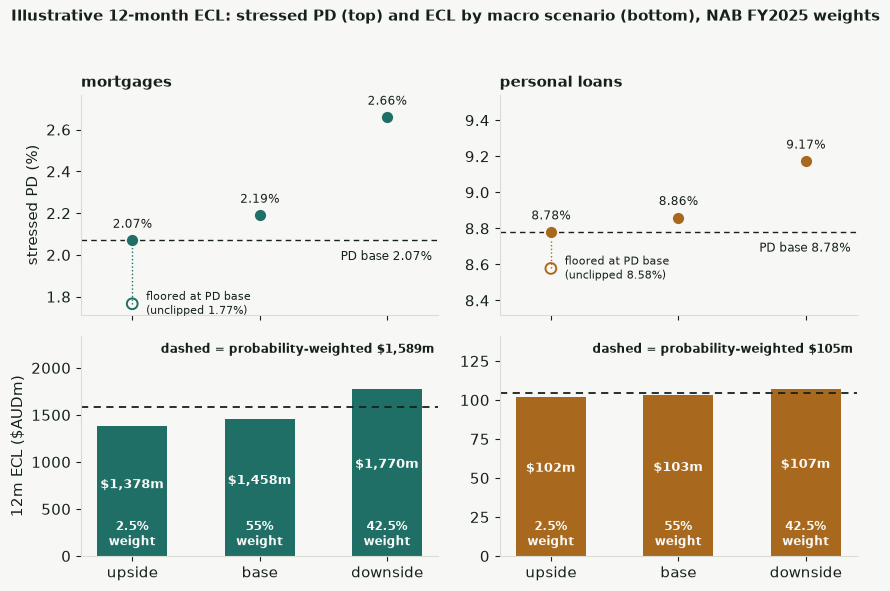

In [3]:
credit = pd.read_csv(TABLEAU / "credit_stress.csv")
order = ["upside", "base", "downside"]
segments = [("mortgages", ACCENT), ("personal_loans", HIGHLIGHT)]

fig, axes = plt.subplots(2, 2, figsize=(8.8, 6.0), sharex=True)
for col, (seg, color) in enumerate(segments):
    sub = credit[credit["segment"] == seg].set_index("scenario").loc[order]
    weighted = sub["ecl_aud_m_12m_probability_weighted"].iloc[0]
    pd_base = sub["pd_base"].iloc[0]
    # Unclipped PD_base + s*du/100; below PD_base for the upside path (falling unemployment)
    raw_pd = sub["pd_base"] + sub["ur_sensitivity"] * sub["delta_unemployment_cumulative"] / 100
    floored = raw_pd < sub["pd_base"]

    top = axes[0, col]
    top.axhline(pd_base * 100, color=INK, linewidth=1.0, linestyle=(0, (4, 3)))
    top.scatter(order, sub["pd_stressed"] * 100, s=90, color=color, edgecolor=PAPER, linewidth=1.4, zorder=3)
    for x, (_, r) in enumerate(sub.iterrows()):
        top.annotate(f"{r['pd_stressed'] * 100:.2f}%", (x, r["pd_stressed"] * 100), xytext=(0, 9),
                     textcoords="offset points", ha="center", fontsize=8.5)
    for x, scenario in enumerate(order):
        if floored[scenario]:
            top.plot([x, x], [raw_pd[scenario] * 100, pd_base * 100], color=color, linewidth=1.0, linestyle=":")
            top.scatter([x], [raw_pd[scenario] * 100], s=60, facecolor="none", edgecolor=color, linewidth=1.4,
                        zorder=3)
            top.annotate(f"floored at PD base\n(unclipped {raw_pd[scenario] * 100:.2f}%)",
                         (x, raw_pd[scenario] * 100), xytext=(10, 0), textcoords="offset points",
                         ha="left", va="center", fontsize=8.2)
    top.annotate(f"PD base {pd_base * 100:.2f}%", (2.35, pd_base * 100), xytext=(0, -7),
                 textcoords="offset points", ha="right", va="top", fontsize=8.5)
    top.set_title(seg.replace("_", " "), loc="left", fontsize=11, fontweight="bold")
    top.set_ylim(min(pd_base * 100 * 0.97, raw_pd.min() * 100 * 0.97),
                 sub["pd_stressed"].max() * 100 * 1.04)
    top.set_ylabel("stressed PD (%)" if col == 0 else "")

    bottom = axes[1, col]
    bottom.bar(order, sub["ecl_aud_m"], color=color, width=0.55)
    for x, (_, r) in enumerate(sub.iterrows()):
        bottom.text(x, sub["ecl_aud_m"].max() * 0.04, f"{r['probability_weight'] * 100:g}%\nweight", ha="center",
                    va="bottom", fontsize=8.5, color=PAPER, fontweight="bold")
        bottom.text(x, r["ecl_aud_m"] * 0.55, f"${r['ecl_aud_m']:,.0f}m", ha="center", va="center", fontsize=9.5,
                    color=PAPER, fontweight="bold")
    bottom.axhline(weighted, color=INK, linewidth=1.3, linestyle=(0, (4, 3)))
    bottom.text(0.99, 0.97, f"dashed = probability-weighted ${weighted:,.0f}m", transform=bottom.transAxes,
                ha="right", va="top", fontsize=8.8, fontweight="bold")
    bottom.set_ylim(0, sub["ecl_aud_m"].max() * 1.32)
    bottom.set_ylabel("12m ECL ($AUDm)" if col == 0 else "")
    for a in (top, bottom):
        a.grid(False)
fig.suptitle("Illustrative 12-month ECL: stressed PD (top) and ECL by macro scenario (bottom), NAB FY2025 weights",
             fontsize=10.5, fontweight="bold", x=0.02, ha="left")
fig.tight_layout(rect=(0, 0, 1, 0.95))
plt.show()

#### References

```{bibliography}
:filter: docname in docnames
```